In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [2]:
# 读取colas.csv数据
data_path = '../../SourceData/colas.csv'
df = pd.read_csv(data_path)

# 转换时间列为datetime格式
df['time'] = pd.to_datetime(df['time'])

# 显示数据基本信息
print("Data Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head(10)

Data Shape: (114253, 11)

Column Names:
['Unnamed: 0', 'id', 'time', 'gl', 'gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']

First few rows:


,Unnamed: 0,id,time,gl,gender,age,BMI,glycaemia,HbA1c,follow.up,T2DM
0,0,1,2012-01-01 00:00:00,86.0,1.0,77.0,25.4,106.0,6.3,413.0,False
1,1,1,2012-01-01 00:05:00,81.0,1.0,77.0,25.4,106.0,6.3,413.0,False
2,2,1,2012-01-01 00:10:00,78.0,1.0,77.0,25.4,106.0,6.3,413.0,False
3,3,1,2012-01-01 00:15:00,76.0,1.0,77.0,25.4,106.0,6.3,413.0,False
4,4,1,2012-01-01 00:20:00,76.0,1.0,77.0,25.4,106.0,6.3,413.0,False
5,5,1,2012-01-01 00:25:00,77.0,1.0,77.0,25.4,106.0,6.3,413.0,False
6,6,1,2012-01-01 00:30:00,78.0,1.0,77.0,25.4,106.0,6.3,413.0,False
7,7,1,2012-01-01 00:35:00,80.0,1.0,77.0,25.4,106.0,6.3,413.0,False
8,8,1,2012-01-01 00:40:00,81.0,1.0,77.0,25.4,106.0,6.3,413.0,False
9,9,1,2012-01-01 00:45:00,82.0,1.0,77.0,25.4,106.0,6.3,413.0,False


In [3]:
# 数据统计摘要
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0,id,time,gl,gender,age,BMI,glycaemia,HbA1c,follow.up
count,114253.00000,114253.000000,114253,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000
mean,57126.00000,103.514551,2012-01-01 23:26:50.525281536,102.320342,0.508503,59.656430,29.960454,100.877038,5.766710,986.276023
min,0.00000,1.000000,2012-01-01 00:00:00,40.000000,0.000000,29.000000,18.100000,78.000000,5.100000,176.000000
25%,28563.00000,51.000000,2012-01-01 11:25:00,88.000000,0.000000,54.000000,27.000000,93.000000,5.600000,701.000000
50%,57126.00000,104.000000,2012-01-01 23:00:01,100.000000,1.000000,61.000000,29.400000,101.000000,5.766710,986.276023
75%,85689.00000,156.000000,2012-01-02 11:25:01,113.000000,1.000000,66.000000,32.400000,108.000000,5.900000,1232.000000
max,114252.00000,208.000000,2012-01-02 23:58:44,318.000000,2.000000,88.000000,48.700000,135.000000,6.500000,2211.000000
std,32982.14449,60.246477,NaN,21.805964,0.509915,9.968358,4.546004,11.359690,0.289851,363.653638


In [4]:
# 检查缺失值
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:
Unnamed: 0    0
id            0
time          0
gl            0
gender        0
age           0
BMI           0
glycaemia     0
HbA1c         0
follow.up     0
T2DM          0
dtype: int64

Missing Percentage:
Unnamed: 0    0.0
id            0.0
time          0.0
gl            0.0
gender        0.0
age           0.0
BMI           0.0
glycaemia     0.0
HbA1c         0.0
follow.up     0.0
T2DM          0.0
dtype: float64


In [5]:
# 获取唯一受试者数量
unique_subjects = df['id'].nunique()
print(f"Number of Unique Subjects: {unique_subjects}")
print(f"\nSubject IDs: {sorted(df['id'].unique())}")

Number of Unique Subjects: 208

Subject IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69

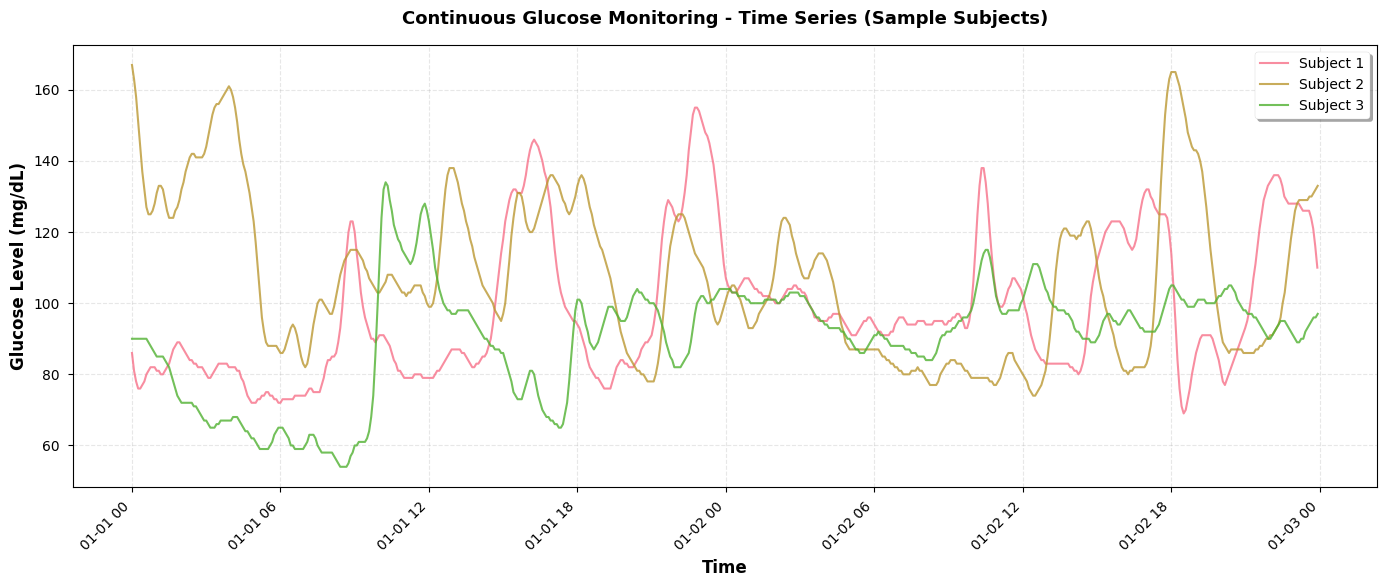

In [6]:
# 图1: 血糖时间序列图 (选择前3个受试者作为示例)
fig, ax = plt.subplots(figsize=(14, 6))

# 选择前3个受试者
sample_subjects = sorted(df['id'].unique())[:3]

for subject_id in sample_subjects:
    subject_data = df[df['id'] == subject_id].sort_values('time')
    ax.plot(subject_data['time'], subject_data['gl'], 
            label=f'Subject {subject_id}', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
ax.set_title('Continuous Glucose Monitoring - Time Series (Sample Subjects)', 
             fontweight='bold', pad=15)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

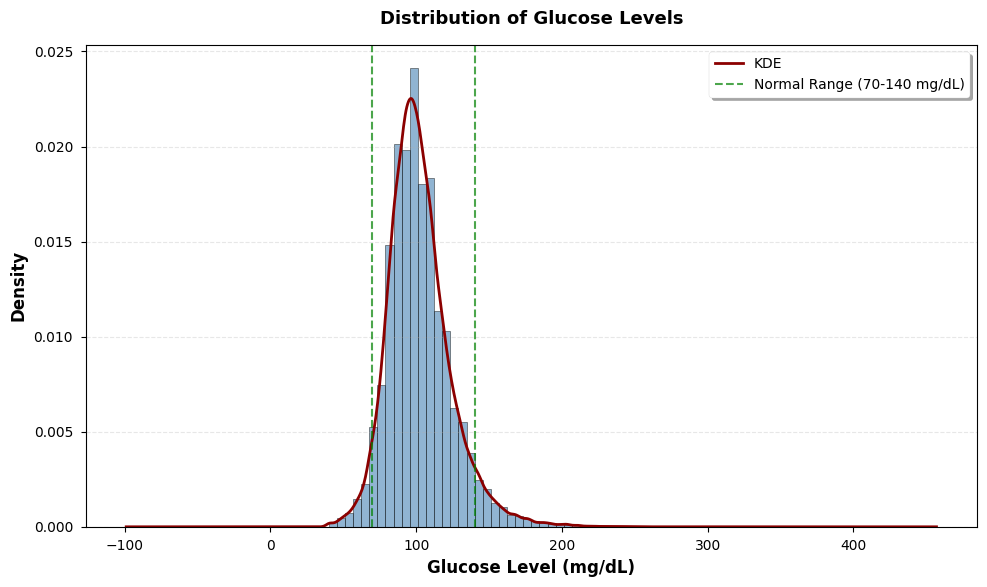

Mean Glucose Level: 102.32 mg/dL
Median Glucose Level: 100.00 mg/dL
Std Dev: 21.81 mg/dL


In [7]:
# 图2: 血糖分布直方图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制直方图和核密度估计
ax.hist(df['gl'].dropna(), bins=50, density=True, alpha=0.6, 
        color='steelblue', edgecolor='black', linewidth=0.5)

# 添加核密度估计曲线
df['gl'].dropna().plot(kind='kde', ax=ax, color='darkred', 
                       linewidth=2, label='KDE')

# 添加参考线（正常血糖范围）
ax.axvline(x=70, color='green', linestyle='--', linewidth=1.5, 
           label='Normal Range (70-140 mg/dL)', alpha=0.7)
ax.axvline(x=140, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Glucose Level (mg/dL)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Distribution of Glucose Levels', fontweight='bold', pad=15)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

# 输出统计信息
print(f"Mean Glucose Level: {df['gl'].mean():.2f} mg/dL")
print(f"Median Glucose Level: {df['gl'].median():.2f} mg/dL")
print(f"Std Dev: {df['gl'].std():.2f} mg/dL")

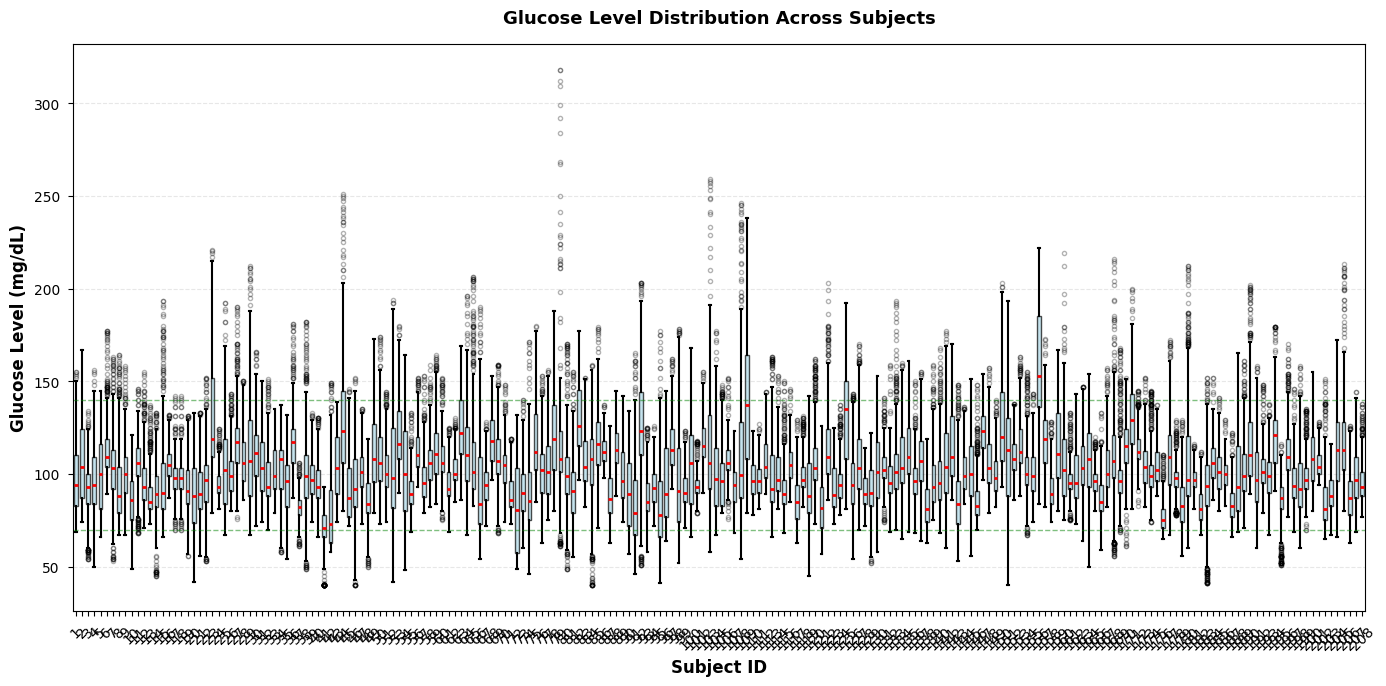

In [8]:
# 图3: 不同受试者的血糖箱线图
fig, ax = plt.subplots(figsize=(14, 7))

# 准备数据用于箱线图
subject_data = [df[df['id'] == sid]['gl'].dropna() for sid in sorted(df['id'].unique())]
positions = range(1, len(subject_data) + 1)

bp = ax.boxplot(subject_data, positions=positions, widths=0.6,
                patch_artist=True, showfliers=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))

ax.set_xlabel('Subject ID', fontweight='bold')
ax.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
ax.set_title('Glucose Level Distribution Across Subjects', fontweight='bold', pad=15)
ax.set_xticks(positions)
ax.set_xticklabels([str(sid) for sid in sorted(df['id'].unique())], rotation=45)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# 添加参考线
ax.axhline(y=70, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=140, color='green', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

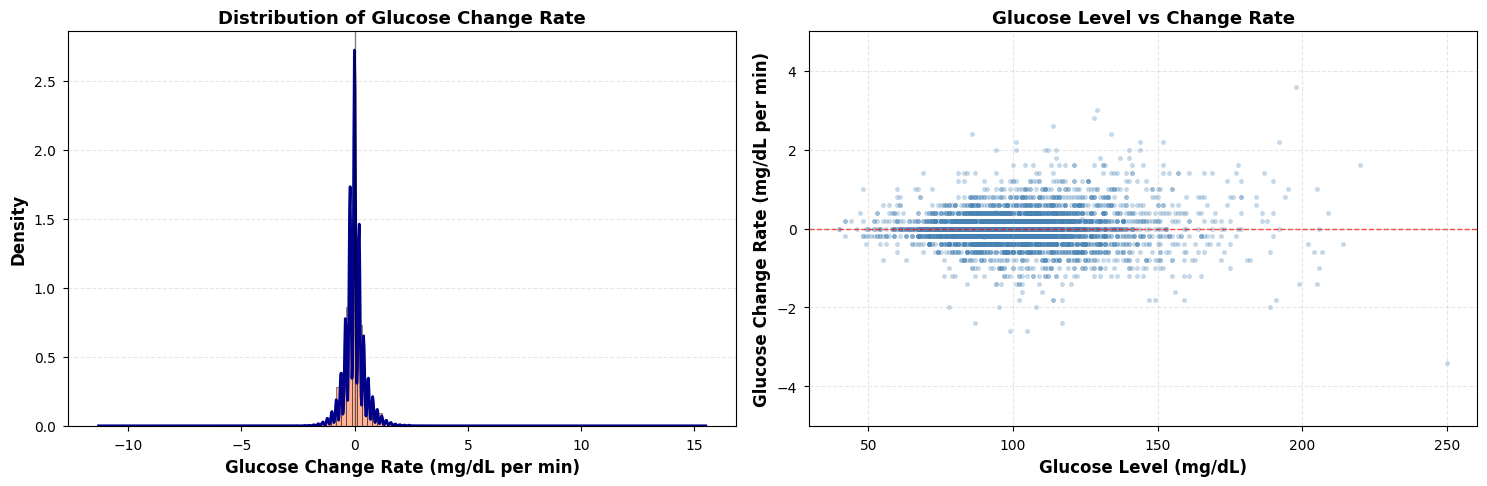

In [9]:
# 图4: 血糖变化率分析
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 计算血糖变化率（按受试者分组）
df_sorted = df.sort_values(['id', 'time'])
df_sorted['gl_diff'] = df_sorted.groupby('id')['gl'].diff()
df_sorted['time_diff'] = df_sorted.groupby('id')['time'].diff().dt.total_seconds() / 60  # 转换为分钟
df_sorted['gl_rate'] = df_sorted['gl_diff'] / df_sorted['time_diff']  # mg/dL per minute

# 子图1: 血糖变化率分布
valid_rates = df_sorted['gl_rate'].dropna()
valid_rates = valid_rates[np.abs(valid_rates) < 10]  # 移除异常值

ax1.hist(valid_rates, bins=60, density=True, alpha=0.6, 
         color='coral', edgecolor='black', linewidth=0.5)
valid_rates.plot(kind='kde', ax=ax1, color='darkblue', linewidth=2)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Glucose Change Rate (mg/dL per min)', fontweight='bold')
ax1.set_ylabel('Density', fontweight='bold')
ax1.set_title('Distribution of Glucose Change Rate', fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# 子图2: 血糖值 vs 变化率散点图
sample_data = df_sorted[['gl', 'gl_rate']].dropna().sample(n=min(5000, len(df_sorted)), random_state=42)
ax2.scatter(sample_data['gl'], sample_data['gl_rate'], 
           alpha=0.3, s=10, color='steelblue')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Glucose Level (mg/dL)', fontweight='bold')
ax2.set_ylabel('Glucose Change Rate (mg/dL per min)', fontweight='bold')
ax2.set_title('Glucose Level vs Change Rate', fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

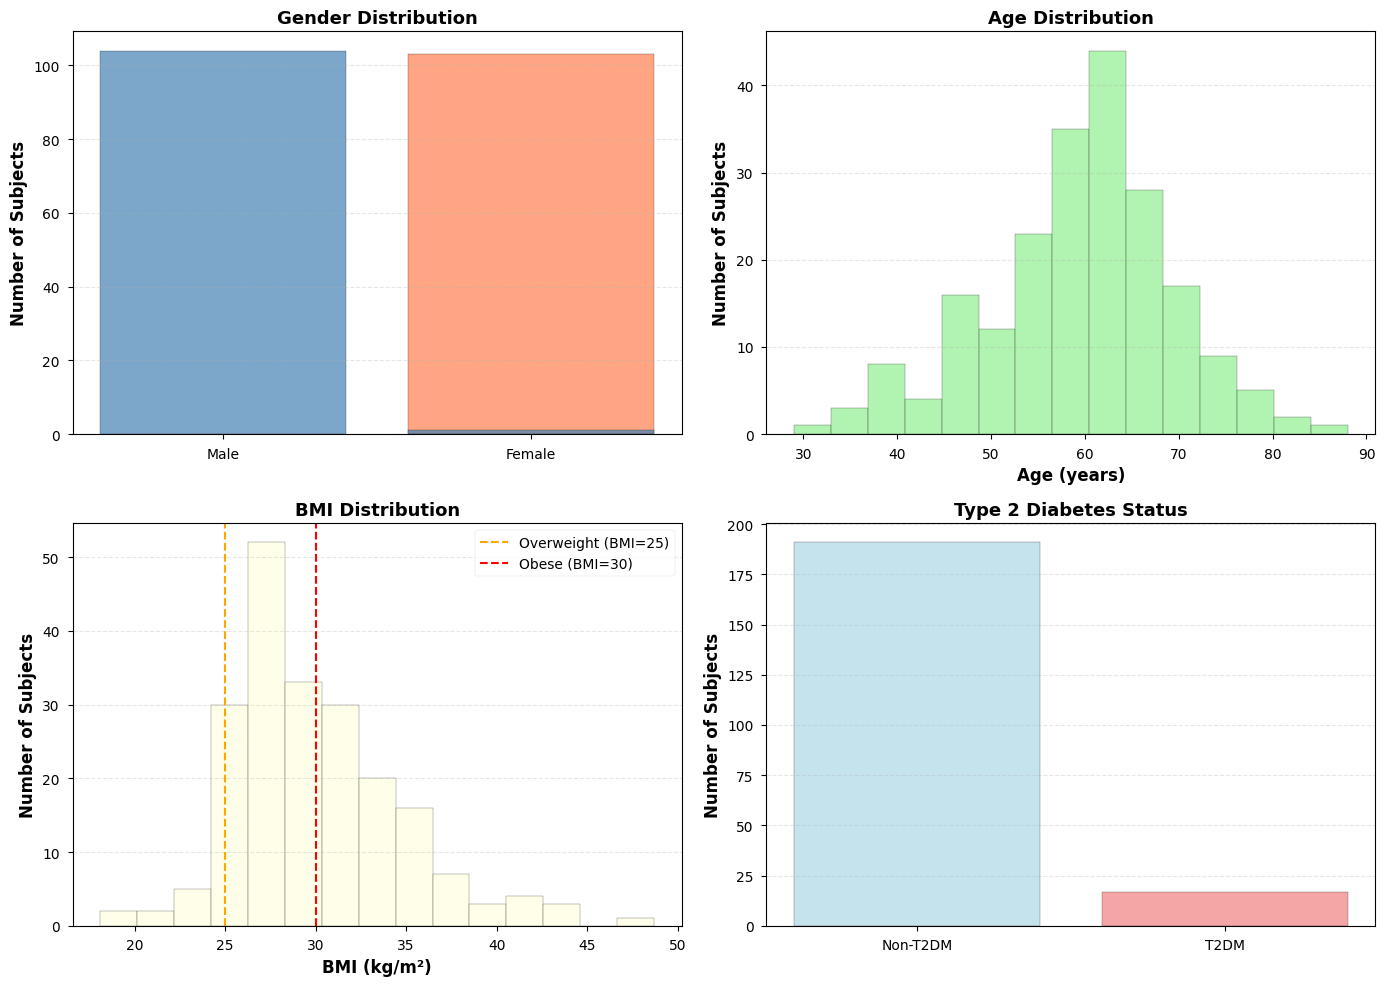


Subject Characteristics Summary:
Average Age: 59.6 years (SD: 10.1)
Average BMI: 30.0 kg/m² (SD: 4.7)
T2DM Subjects: 17 (8.2%)


In [10]:
# 图5: 患者特征分析（性别、年龄、BMI、T2DM状态）
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 获取每个受试者的唯一特征
subject_features = df.groupby('id').first()[['gender', 'age', 'BMI', 'T2DM']]

# 子图1: 性别分布
gender_counts = subject_features['gender'].value_counts()
axes[0, 0].bar(['Male' if g == 1.0 else 'Female' for g in gender_counts.index], 
               gender_counts.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Number of Subjects', fontweight='bold')
axes[0, 0].set_title('Gender Distribution', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, linestyle='--', axis='y')

# 子图2: 年龄分布
axes[0, 1].hist(subject_features['age'].dropna(), bins=15, 
                color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Age (years)', fontweight='bold')
axes[0, 1].set_ylabel('Number of Subjects', fontweight='bold')
axes[0, 1].set_title('Age Distribution', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, linestyle='--', axis='y')

# 子图3: BMI分布
axes[1, 0].hist(subject_features['BMI'].dropna(), bins=15, 
                color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=25, color='orange', linestyle='--', linewidth=1.5, label='Overweight (BMI=25)')
axes[1, 0].axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='Obese (BMI=30)')
axes[1, 0].set_xlabel('BMI (kg/m²)', fontweight='bold')
axes[1, 0].set_ylabel('Number of Subjects', fontweight='bold')
axes[1, 0].set_title('BMI Distribution', fontweight='bold')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3, linestyle='--', axis='y')

# 子图4: T2DM状态
t2dm_counts = subject_features['T2DM'].value_counts()
colors_t2dm = ['lightblue' if not x else 'lightcoral' for x in t2dm_counts.index]
axes[1, 1].bar(['Non-T2DM' if not t else 'T2DM' for t in t2dm_counts.index], 
               t2dm_counts.values, color=colors_t2dm, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Number of Subjects', fontweight='bold')
axes[1, 1].set_title('Type 2 Diabetes Status', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

# 输出统计信息
print("\nSubject Characteristics Summary:")
print(f"Average Age: {subject_features['age'].mean():.1f} years (SD: {subject_features['age'].std():.1f})")
print(f"Average BMI: {subject_features['BMI'].mean():.1f} kg/m² (SD: {subject_features['BMI'].std():.1f})")
print(f"T2DM Subjects: {subject_features['T2DM'].sum()} ({subject_features['T2DM'].sum()/len(subject_features)*100:.1f}%)")

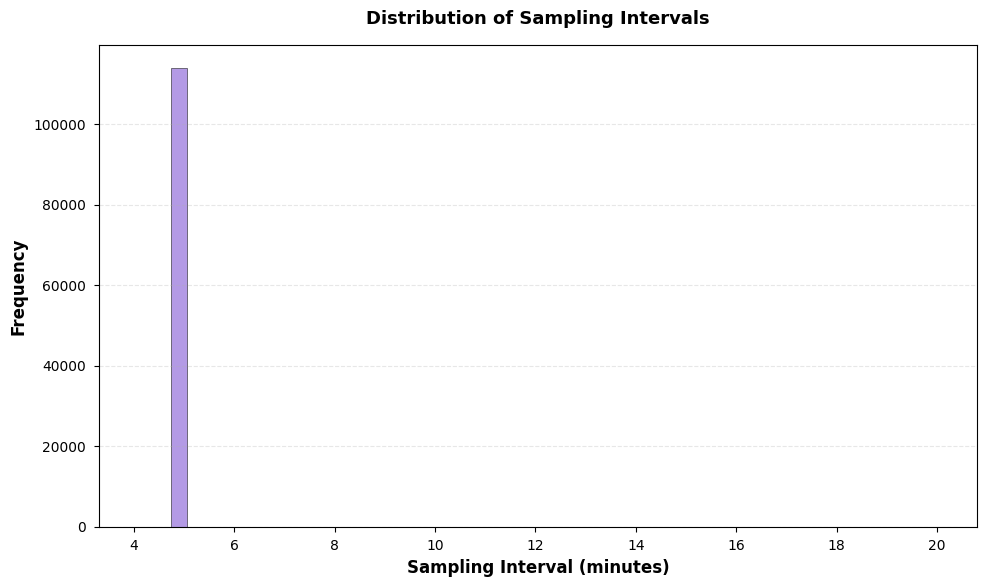


Mean Sampling Interval: 5.00 minutes
Median Sampling Interval: 5.00 minutes
Mode Sampling Interval: 5.00 minutes


In [11]:
# 图6: 数据采样间隔分析
fig, ax = plt.subplots(figsize=(10, 6))

# 计算采样间隔（分钟）
sampling_intervals = df_sorted['time_diff'].dropna()
sampling_intervals = sampling_intervals[sampling_intervals < 30]  # 仅显示<30分钟的间隔

ax.hist(sampling_intervals, bins=50, color='mediumpurple', 
        alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Sampling Interval (minutes)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution of Sampling Intervals', fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

print(f"\nMean Sampling Interval: {sampling_intervals.mean():.2f} minutes")
print(f"Median Sampling Interval: {sampling_intervals.median():.2f} minutes")
print(f"Mode Sampling Interval: {sampling_intervals.mode().values[0]:.2f} minutes")

In [12]:
# 数据质量报告总结
print("="*60)
print("DATA QUALITY REPORT - COLAS.CSV")
print("="*60)
print(f"\n1. Dataset Size:")
print(f"   - Total Records: {len(df):,}")
print(f"   - Number of Subjects: {df['id'].nunique()}")
print(f"   - Time Range: {df['time'].min()} to {df['time'].max()}")
print(f"\n2. Missing Data:")
for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df) * 100)
    if missing_pct > 0:
        print(f"   - {col}: {missing_pct:.2f}%")
print(f"\n3. Glucose Level Statistics:")
print(f"   - Mean: {df['gl'].mean():.2f} mg/dL")
print(f"   - Median: {df['gl'].median():.2f} mg/dL")
print(f"   - Range: [{df['gl'].min():.2f}, {df['gl'].max():.2f}] mg/dL")
print(f"   - SD: {df['gl'].std():.2f} mg/dL")
print(f"\n4. Data Consistency:")
print(f"   - Mean Sampling Interval: {df_sorted['time_diff'].mean():.2f} minutes")
print(f"   - Records per Subject (avg): {len(df)/df['id'].nunique():.0f}")
print("="*60)

DATA QUALITY REPORT - COLAS.CSV

1. Dataset Size:
   - Total Records: 114,253
   - Number of Subjects: 208
   - Time Range: 2012-01-01 00:00:00 to 2012-01-02 23:58:44

2. Missing Data:

3. Glucose Level Statistics:
   - Mean: 102.32 mg/dL
   - Median: 100.00 mg/dL
   - Range: [40.00, 318.00] mg/dL
   - SD: 21.81 mg/dL

4. Data Consistency:
   - Mean Sampling Interval: 5.03 minutes
   - Records per Subject (avg): 549
